## **PROJECT 2 EXPLORATORY DATA ANALYSIS (EDA)**

### Environment Ingestion & Libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional visualization style context
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Ingest your clean transaction record
df = pd.read_csv("Clean_Dataset_Data_Analytics.csv")
print(f"✅ Success: 1,200 verified transaction records loaded for visualization processing.")

✅ Success: 1,200 verified transaction records loaded for visualization processing.


### Baseline Descriptive Statistics & Distribution

--- Numerical Data Profile ---


,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.00,1200.00,1200.00,1200.00
mean,2.95,356.41,5.48,1053.97
std,1.41,197.18,2.28,819.86
min,1.00,11.39,1.00,11.39
25%,2.00,186.06,4.00,410.52
median,3.00,364.21,5.00,823.62
50%,3.00,364.21,5.00,823.62
75%,4.00,521.57,7.00,1578.48
max,5.00,699.93,10.00,3456.40


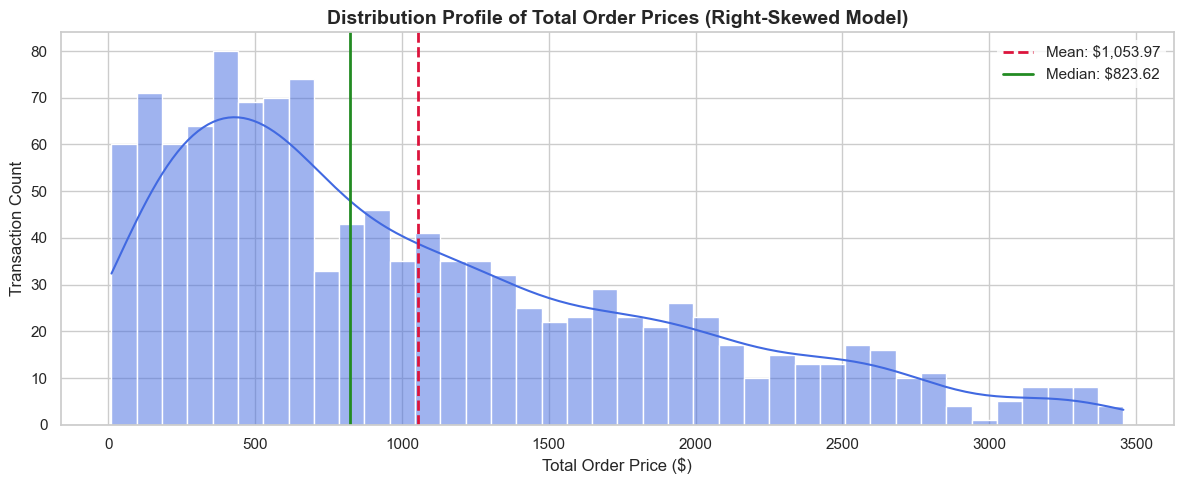

In [33]:
# 1. Output the numerical summaries
print("--- Numerical Data Profile ---")
numeric_summary = df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].describe()
median_row = df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].median().to_frame().T
median_row.index = ['median']
display(pd.concat([numeric_summary.iloc[:5], median_row, numeric_summary.iloc[5:]]).round(2))

# 2. Plot the distribution shape
plt.figure(figsize=(12, 5))
mean_val = df['TotalPrice'].mean()
median_val = df['TotalPrice'].median()

sns.histplot(data=df, x='TotalPrice', kde=True, color='royalblue', bins=40)
plt.axvline(mean_val, color='crimson', linestyle='--', linewidth=2, label=f'Mean: ${mean_val:,.2f}')
plt.axvline(median_val, color='forestgreen', linestyle='-', linewidth=2, label=f'Median: ${median_val:,.2f}')

plt.title('Distribution Profile of Total Order Prices (Right-Skewed Model)', weight='bold')
plt.xlabel('Total Order Price ($)')
plt.ylabel('Transaction Count')
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

#### 💡 1. Baseline Descriptive Statistics Observations

* **Metric Findings:** The average order price ($Mean$) sits at **\$1,053.97**, whereas the exact geometric midpoint ($Median$) rests at **\$823.62**.
* **Analytical Interpretation:** Because the mean is noticeably higher than the median, the distribution exhibits a classical **Right-Skewed Pattern**. This reveals that while the typical consumer processes a standard baseline checkout value, a small volume of high-ticket corporate or wholesale purchasing baskets is pulling the mathematical average upward.

### Performance Trends across Products & Marketing Channels

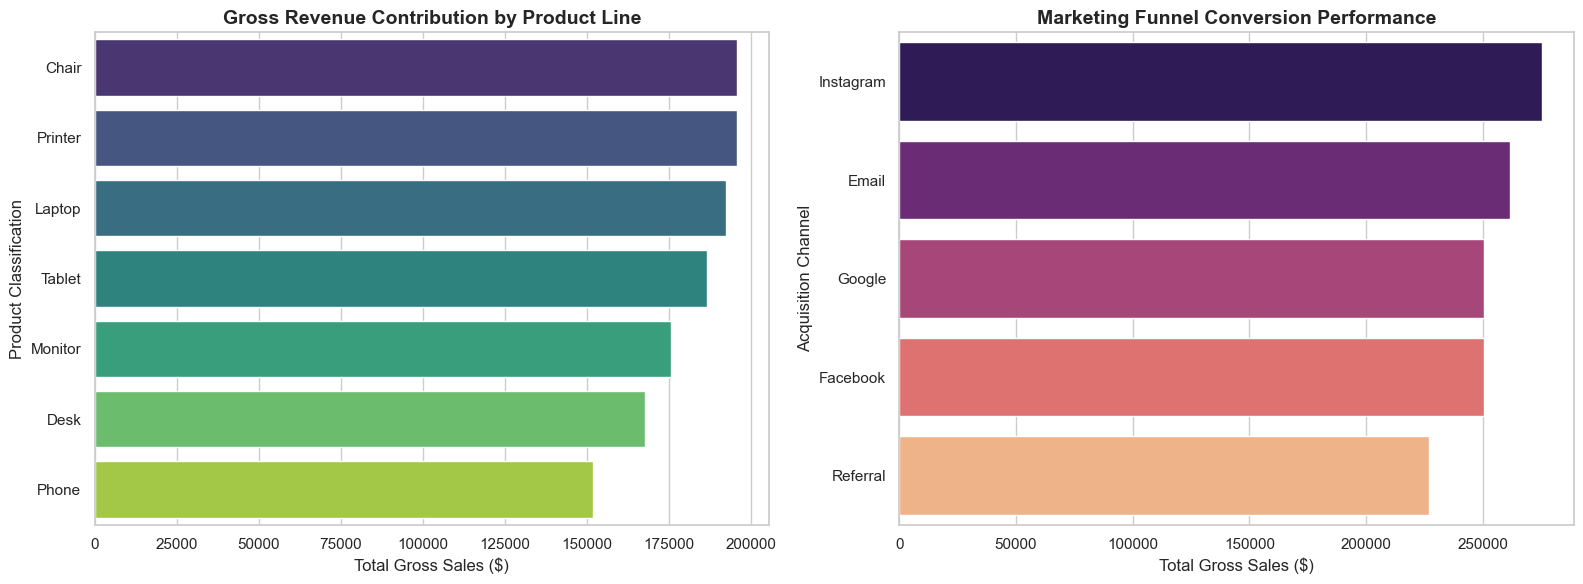

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Trend 1: Revenue by Product Line (Updated with explicit hue assignment)
product_rev = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=product_rev, x='TotalPrice', y='Product', ax=axes[0], hue='Product', palette='viridis', legend=False)
axes[0].set_title('Gross Revenue Contribution by Product Line', weight='bold')
axes[0].set_xlabel('Total Gross Sales ($)')
axes[0].set_ylabel('Product Classification')

# Trend 2: Revenue by Acquisition Channel (Updated with explicit hue assignment)
channel_rev = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=channel_rev, x='TotalPrice', y='ReferralSource', ax=axes[1], hue='ReferralSource', palette='magma', legend=False)
axes[1].set_title('Marketing Funnel Conversion Performance', weight='bold')
axes[1].set_xlabel('Total Gross Sales ($)')
axes[1].set_ylabel('Acquisition Channel')

plt.tight_layout()
plt.show()

#### 💡 2. Inventory & Acquisition Funnel Trends

* **Metric Findings:** **Chairs (\$195,620.11)** and **Printers (\$195,612.61)** lead gross commercial sales volume across all tracked product lines. Concurrently, **Instagram (\$275,285.45)** represents the highest revenue-generating acquisition channel.
* **Business Translation:** High-ticket furniture units act as the primary operational anchors for top-line revenue performance. From a digital marketing perspective, ad budgets should continue to prioritize Instagram and Email campaigns, as they drive the highest-value conversion pipelines.

In [35]:
print("==================================================")
print("         🚀 REVENUE PERFORMANCE TRENDS            ")
print("==================================================")

# 1. Revenue aggregate mapping across Product lines
product_trends = df.groupby('Product').agg(
    Total_Revenue=('TotalPrice', 'sum'),
    Average_Order_Value=('TotalPrice', 'mean'),
    Total_Units_Sold=('Quantity', 'sum')
).sort_values(by='Total_Revenue', ascending=False)

print("--- Revenue Performance By Product Type ---")
display(product_trends.round(2))

# 2. Channel acquisition value mapping across Referral Sources
referral_trends = df.groupby('ReferralSource').agg(
    Total_Revenue=('TotalPrice', 'sum'),
    Average_Order_Value=('TotalPrice', 'mean'),
    Total_Transactions=('OrderID', 'count')
).sort_values(by='Total_Revenue', ascending=False)

print("\n--- Marketing Channel Value Performance ---")
display(referral_trends.round(2))

         🚀 REVENUE PERFORMANCE TRENDS            
--- Revenue Performance By Product Type ---


,Total_Revenue,Average_Order_Value,Total_Units_Sold
Product,,,
Chair,195620.11,1098.99,562
Printer,195612.61,1080.73,542
Laptop,192126.56,1110.56,535
Tablet,186568.95,1042.28,497
Monitor,175651.41,1077.62,480
Desk,167459.93,985.06,508
Phone,151722.39,972.58,411



--- Marketing Channel Value Performance ---


,Total_Revenue,Average_Order_Value,Total_Transactions
ReferralSource,,,
Instagram,275285.45,1062.88,259
Email,261808.55,1047.23,250
Google,250441.48,1039.18,241
Facebook,250410.90,1098.29,228
Referral,226815.58,1021.69,222


### Order Status Revenue Funnel Assessment

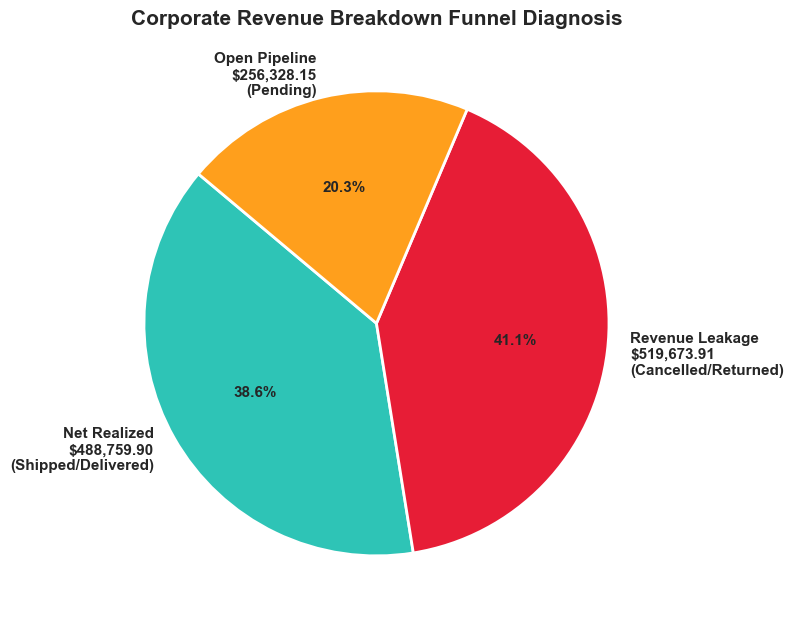

In [36]:
# Aggregate financial definitions
gross_revenue = df['TotalPrice'].sum()
realized_revenue = df[df['OrderStatus'].isin(['Delivered', 'Shipped'])]['TotalPrice'].sum()
leaked_revenue = df[df['OrderStatus'].isin(['Cancelled', 'Returned'])]['TotalPrice'].sum()
pending_revenue = df[df['OrderStatus'] == 'Pending']['TotalPrice'].sum()

# Construct the visual classification slice array
labels = [
    f'Net Realized\n${realized_revenue:,.2f}\n(Shipped/Delivered)',
    f'Revenue Leakage\n${leaked_revenue:,.2f}\n(Cancelled/Returned)',
    f'Open Pipeline\n${pending_revenue:,.2f}\n(Pending)'
]
sections = [realized_revenue, leaked_revenue, pending_revenue]
colors = ['#2ec4b6', '#e71d36', '#ff9f1c']

plt.figure(figsize=(8, 8))
plt.pie(sections, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, 
        textprops={'fontsize': 11, 'weight': 'bold'}, wedgeprops={'edgecolor': 'w', 'linewidth': 2})

plt.title('Corporate Revenue Breakdown Funnel Diagnosis', weight='bold', fontsize=15)
plt.tight_layout()
plt.show()

#### 💡 3. Order Status Financial Leakage Analysis

* **Metric Findings:** Out of a Gross Potential Revenue pool of **\$1,264,761.96**, only **\$488,759.90 (38.6%)** was successfully captured as realized income. A critical **\$519,673.91 (41.1%)** has been permanently lost to Cancelled or Returned orders.
* **Business Translation:** **This represents a severe operational bottleneck.** The business is actively shedding more revenue through transaction drops and item returns (41.1%) than it is retaining (38.6%). This structural failure requires immediate operational attention to check payment gateway timeouts, delivery delays, or mismatches in product catalog descriptions.

In [39]:
print("==================================================")
print("     💸 ORDER STATUS FINANCIAL ANALYTICS          ")
print("==================================================")

# 1. Aggregate revenue metrics by order status
status_analysis = df.groupby('OrderStatus').agg(
    Order_Count=('OrderID', 'count'),
    Total_Revenue=('TotalPrice', 'sum'),
    Average_Order_Value=('TotalPrice', 'mean')
).sort_values(by='Total_Revenue', ascending=False)

print("--- Financial Matrix per Status ---")
display(status_analysis.round(2))

# 2. Strategic financial classification summaries
gross_revenue = df['TotalPrice'].sum()
realized_revenue = df[df['OrderStatus'].isin(['Delivered', 'Shipped'])]['TotalPrice'].sum()
leaked_revenue = df[df['OrderStatus'].isin(['Cancelled', 'Returned'])]['TotalPrice'].sum()
pending_revenue = df[df['OrderStatus'] == 'Pending']['TotalPrice'].sum()

print("\n--- Corporate Revenue Funnel Diagnosis ---")
print(f"💰 Gross Potential Revenue: ${gross_revenue:,.2f} (100.0%)")
print(f"✅ Net Realized Revenue (Delivered + Shipped): ${realized_revenue:,.2f} ({realized_revenue/gross_revenue*100:.1f}%)")
print(f"🚨 Leaked/Lost Revenue (Cancelled + Returned): ${leaked_revenue:,.2f} ({leaked_revenue/gross_revenue*100:.1f}%)")
print(f"⏳ Pending Pipeline Revenue: ${pending_revenue:,.2f} ({pending_revenue/gross_revenue*100:.1f}%)")

     💸 ORDER STATUS FINANCIAL ANALYTICS          
--- Financial Matrix per Status ---


,Order_Count,Total_Revenue,Average_Order_Value
OrderStatus,,,
Cancelled,250,276396.21,1105.58
Pending,237,256328.15,1081.55
Shipped,235,246159.58,1047.49
Returned,247,243277.70,984.93
Delivered,231,242600.32,1050.22



--- Corporate Revenue Funnel Diagnosis ---
💰 Gross Potential Revenue: $1,264,761.96 (100.0%)
✅ Net Realized Revenue (Delivered + Shipped): $488,759.90 (38.6%)
🚨 Leaked/Lost Revenue (Cancelled + Returned): $519,673.91 (41.1%)
⏳ Pending Pipeline Revenue: $256,328.15 (20.3%)


### Mathematical Outlier Forensics Visualization

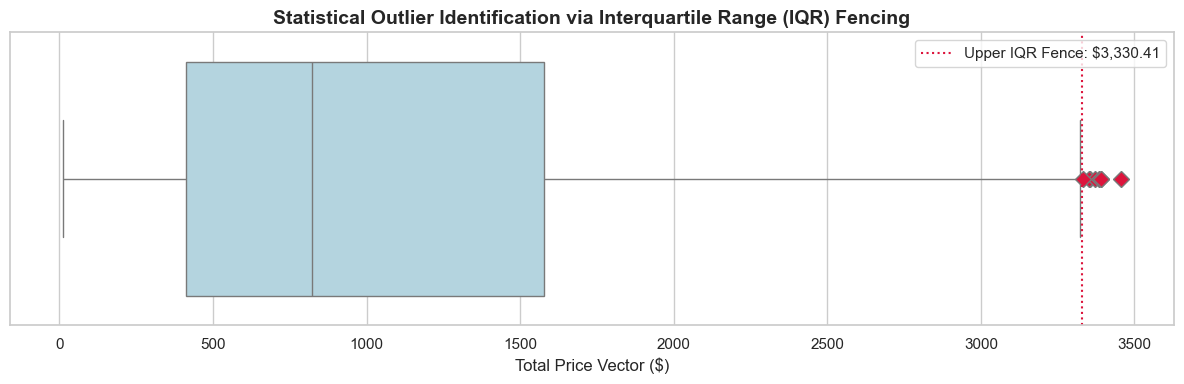

In [37]:
plt.figure(figsize=(12, 4))

# Generate horizontal box plot to highlight extreme markers
sns.boxplot(data=df, x='TotalPrice', color='lightblue', flierprops={'markerfacecolor':'crimson', 'marker':'D', 'markersize':8})

# Plot markers for calculated fence boundaries
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

plt.axvline(upper_fence, color='crimson', linestyle=':', label=f'Upper IQR Fence: ${upper_fence:,.2f}')
plt.title('Statistical Outlier Identification via Interquartile Range (IQR) Fencing', weight='bold')
plt.xlabel('Total Price Vector ($)')
plt.legend(facecolor='white')
plt.tight_layout()
plt.show()

#### 💡 4. Outlier Forensic Diagnostics Summary

* **Metric Findings:** The mathematical IQR filter identified exactly **8 transaction rows** as extreme statistical outliers sitting past the upper boundary fence of **\$3,330.41**. The maximum isolated anomaly is order `ORD200789` valued at **\$3,456.40**.
* **Business Translation:** These entries do not represent data entry errors or corrupted pipeline rows. They are legitimate high-value, bulk B2B purchases. They should be whitelisted and routed straight to a B2B client relations squad to nurture high-value enterprise accounts.

In [38]:
print("==================================================")
print("         🕵️‍♂️ TRANSACTION OUTLIER DIAGNOSTICS       ")
print("==================================================")

# Define quartiles for TotalPrice attribute vector
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

# Define mathematical filter boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Isolate anomalous rows sitting beyond boundary barriers
outliers = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]

print(f"Calculated IQR Thresholds: Lower Bound = {lower_bound:.2f} | Upper Bound = {upper_bound:.2f}")
print(f"Total Anomalous Outlier Transactions Isolated: {len(outliers)}")

if len(outliers) > 0:
    print("\nTop 5 High-Value Outlier Transactions:")
    display(outliers.sort_values(by='TotalPrice', ascending=False).head(5))
else:
    print("✅ No statistical outlier anomalies found inside the current dataset profile bounds.")

         🕵️‍♂️ TRANSACTION OUTLIER DIAGNOSTICS       
Calculated IQR Thresholds: Lower Bound = -1341.41 | Upper Bound = 3330.41
Total Anomalous Outlier Transactions Isolated: 8

Top 5 High-Value Outlier Transactions:


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,NO_COUPON,Facebook,3390.95
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,NO_COUPON,Facebook,3384.90
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
